--- Running Experiment 1: Phase Transition (Annealed + Ensemble Averaged) ---
Simulating N=80 (eq_steps=1000) over 3 trials...
  Trial 1/3 done.
  Trial 2/3 done.
  Trial 3/3 done.
Finished N=80 total in 13.59s

Simulating N=320 (eq_steps=1000) over 3 trials...
  Trial 1/3 done.
  Trial 2/3 done.
  Trial 3/3 done.
Finished N=320 total in 38.09s

Simulating N=1280 (eq_steps=1998) over 3 trials...
  Trial 1/3 done.
  Trial 2/3 done.
  Trial 3/3 done.
Finished N=1280 total in 232.91s

Simulating N=5120 (eq_steps=3999) over 3 trials...
  Trial 1/3 done.
  Trial 2/3 done.
  Trial 3/3 done.
Finished N=5120 total in 1567.19s

Simulating N=20480 (eq_steps=7998) over 3 trials...
  Trial 1/3 done.
  Trial 2/3 done.
  Trial 3/3 done.
Finished N=20480 total in 12374.15s



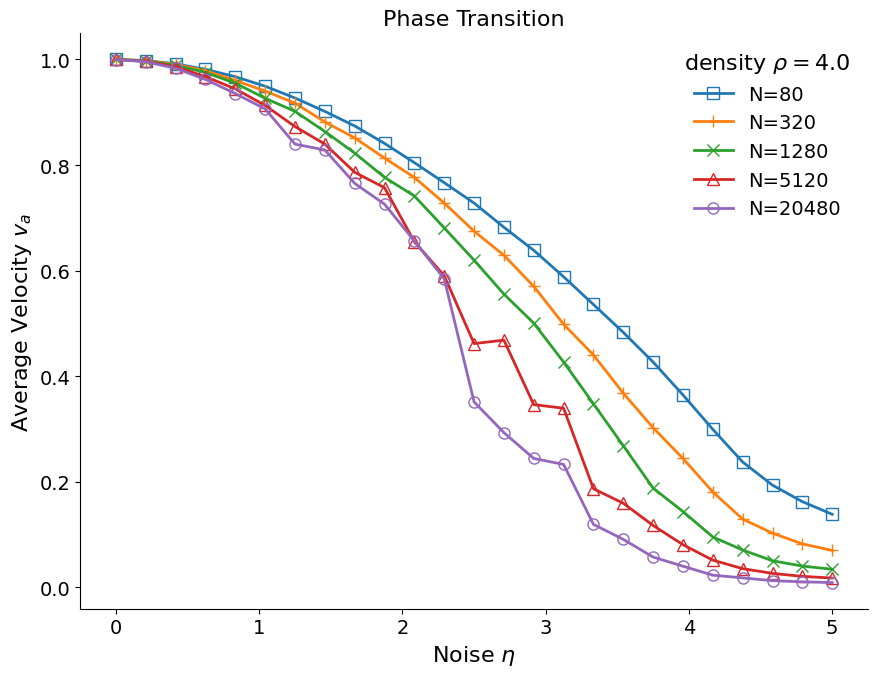

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# =============================================================================
# --- CORE SIMULATION ---
# =============================================================================

@njit
def vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y):
    """
    Advances the Vicsek simulation by a single time step.
    
    Instead of checking every particle against every other particle (which takes O(N^2) time),
    this uses a 'Linked-Cell List' algorithm to reduce the time complexity to O(N). 
    The simulation space is divided into a grid, and particles only look for neighbors 
    in their own cell and the 8 adjacent cells.
    """
    new_theta = np.zeros(N)
    r_sq = r_c**2
    
    total_cells = num_cells_x * num_cells_y
    # 'head' stores the index of the first particle found in each cell.
    head = np.full(total_cells, -1, dtype=np.int32)
    # 'lscl' (linked-cell list) acts as a chain, linking to the next particle in the same cell.
    lscl = np.full(N, -1, dtype=np.int32)
    
    # Step 1: Assign particles to their respective grid cells
    for i in range(N):
        cx = int(pos[i, 0] / cell_size_x) % num_cells_x
        cy = int(pos[i, 1] / cell_size_y) % num_cells_y
        c = cx + cy * num_cells_x 
        
        # Link the current particle to the previous "head" of this cell, then update the head
        lscl[i] = head[c]
        head[c] = i

    # Step 2: Calculate local neighborhood angles for each particle
    for cx in range(num_cells_x):
        for cy in range(num_cells_y):
            c = cx + cy * num_cells_x
            i = head[c]
            
            # Traverse all particles in the current cell
            while i != -1:
                sin_sum, cos_sum = 0.0, 0.0
                
                # Check the current cell and its 8 surrounding neighbors (accounting for boundaries)
                for dx_cell in (-1, 0, 1):
                    for dy_cell in (-1, 0, 1):
                        nx = (cx + dx_cell) % num_cells_x
                        ny = (cy + dy_cell) % num_cells_y
                        nc = nx + ny * num_cells_x
                        
                        j = head[nc]
                        # Traverse all particles in the neighbor cell
                        while j != -1:
                            dx = pos[j, 0] - pos[i, 0]
                            dy = pos[j, 1] - pos[i, 1]
                            
                            # Apply Minimum Image Convention (Periodic Boundary Conditions)
                            # This ensures distance is calculated correctly across the edges of the box.
                            dx -= Lx * np.round(dx / Lx)
                            dy -= Ly * np.round(dy / Ly)
                            
                            # If particle 'j' is within the interaction radius of particle 'i', include its heading
                            if dx**2 + dy**2 <= r_sq:
                                sin_sum += np.sin(theta[j])
                                cos_sum += np.cos(theta[j])
                            
                            # Move to the next particle in the linked list
                            j = lscl[j]
                
                # Step 3: Compute the new heading
                # Average the direction of all neighbors, then add a random uniform noise bounded by 'eta'
                avg_theta = np.arctan2(sin_sum, cos_sum)
                noise = (np.random.rand() - 0.5) * eta
                new_theta[i] = avg_theta + noise
                
                # Move to the next particle in the current cell
                i = lscl[i]

    # Step 4: Update particle positions based on their new headings
    for i in range(N):
        theta[i] = new_theta[i]
        # Move forward by velocity 'v' and wrap around edges (Periodic Boundaries)
        pos[i, 0] = (pos[i, 0] + v * np.cos(theta[i])) % Lx
        pos[i, 1] = (pos[i, 1] + v * np.sin(theta[i])) % Ly
        
    return pos, theta

@njit
def run_rect_simulation(pos, theta, N, Lx, Ly, v, eta, steps, eq_steps):
    """
    Manages the lifecycle of a simulation for a specific noise level.
    It splits the run into an 'equilibration' phase (to let the system settle)
    and a 'measurement' phase (to gather data).
    """
    r_c = 1.0  # Interaction radius (standardized to 1.0)
    
    # Dynamically size the grid cells to be at least as large as the interaction radius.
    num_cells_x = max(1, int(Lx / r_c))
    num_cells_y = max(1, int(Ly / r_c))
    cell_size_x = Lx / num_cells_x 
    cell_size_y = Ly / num_cells_y
    
    # Phase 1: Equilibration
    # Run the system without collecting data so it can reach a steady state.
    for _ in range(eq_steps):
        pos, theta = vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y)
        
    va_accum = 0.0
    measure_steps = steps - eq_steps
    
    # Phase 2: Measurement
    # Run the system and measure the global order parameter (average velocity vector) at each step.
    for _ in range(measure_steps):
        pos, theta = vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y)
        
        # Calculate the macroscopic order parameter (va). 
        # va approaches 1 if all particles move together, and 0 if movement is entirely random.
        vx, vy = np.sum(np.cos(theta)), np.sum(np.sin(theta))
        va_accum += np.sqrt(vx**2 + vy**2) / N
        
    # Return the time-averaged order parameter and the final state of the system
    return va_accum / measure_steps, pos, theta

# =============================================================================
# --- MAIN EXECUTION ---
# =============================================================================

def configure_matplotlib():
    """Applies global font size settings for publication-quality plots."""
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'lines.linewidth': 2,
        'lines.markersize': 8
    })

def main():
    """
    Main execution block for the finite-size scaling experiment.
    We observe how the phase transition (from chaotic movement to organized flocking)
    scales as the system size (N) increases while density remains constant.
    """
    v = 0.03
    num_trials = 3  # Multiple trials to smooth out statistical anomalies

    configure_matplotlib()

    print("--- Running Experiment 1: Phase Transition (Annealed + Ensemble Averaged) ---")

    # Define the systems to test. Note that N / (Lx * Ly) = 4.0 for all configurations,
    # keeping the particle density strictly constant across different system sizes.
    rect_systems = [
        (80, 5.0, 4.0),
        (320, 10.0, 8.0),
        (1280, 20.0, 16.0),
        (5120, 40.0, 32.0),
        (20480, 80.0, 64.0) 
    ]

    # 'Annealing' approach: We start with high noise (chaos) and gradually lower it.
    # Passing the previous state into the next, lower-noise simulation helps the system find its natural flocking state faster.
    eta_values_descending = np.linspace(5.0, 0.0, 25)

    markers = ['s', '+', 'x', '^', 'o']
    plt.figure(figsize=(9, 7))

    # Loop over each system size configuration
    for idx, (N_val, Lx_val, Ly_val) in enumerate(rect_systems):
        va_eta_averaged = np.zeros(len(eta_values_descending))

        # Dynamic equilibration: Larger systems suffer from "critical slowing down" near the phase transition,
        # meaning they take much longer to organize. We calculate required time steps based on box size.
        base_eq_time = int(max(Lx_val, Ly_val) / v)
        eq_steps = max(1000, base_eq_time * 3)
        steps = eq_steps + 2000

        print(f"Simulating N={N_val} (eq_steps={eq_steps}) over {num_trials} trials...")
        start_time_system = time.time()

        for trial in range(num_trials):
            va_trial_results = []

            # Initialize random positions and angles using fast NumPy vectorization
            pos = np.zeros((N_val, 2))
            pos[:, 0] = np.random.rand(N_val) * Lx_val
            pos[:, 1] = np.random.rand(N_val) * Ly_val
            theta = np.random.rand(N_val) * 2 * np.pi - np.pi

            # Sweep down the noise levels (Annealing process)
            for eta in eta_values_descending:
                va, pos, theta = run_rect_simulation(
                    pos, theta, N_val, Lx_val, Ly_val, v, eta, steps=steps, eq_steps=eq_steps
                )
                va_trial_results.append(va)

            # Accumulate this trial's results for later averaging
            va_eta_averaged += np.array(va_trial_results)
            print(f"  Trial {trial+1}/{num_trials} done.")

        # Average the order parameter across all trials for this specific system size
        va_eta_averaged /= num_trials
        print(f"Finished N={N_val} total in {time.time() - start_time_system:.2f}s\n")

        # Reverse the arrays for plotting so the x-axis reads naturally from 0.0 (ordered) to 5.0 (disordered)
        eta_plot = eta_values_descending[::-1]
        va_plot = va_eta_averaged[::-1]

        # Plot the curve for this system size
        plt.plot(
            eta_plot, va_plot,
            linestyle='-', marker=markers[idx], mfc='none', label=f'N={N_val}'
        )

    # --- Formatted Plotting Section ---
    plt.xlabel(r'Noise $\eta$')
    plt.ylabel(r'Average Velocity $v_a$')
    plt.title('Phase Transition')

    # Add legend, noting the constant density across all runs
    plt.legend(title=r'density $\rho=4.0$', title_fontsize=16, frameon=False)

    # Clean up the chart borders for a modern, scientific look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

--- Running Experiment 2: Effect of Density on Flocking ---
Simulating rho=0.10 (N=40) over 5 trials... v_a = 0.196
Simulating rho=0.51 (N=205) over 5 trials... v_a = 0.278
Simulating rho=0.93 (N=370) over 5 trials... v_a = 0.357
Simulating rho=1.34 (N=535) over 5 trials... v_a = 0.498
Simulating rho=1.75 (N=700) over 5 trials... v_a = 0.560
Simulating rho=2.16 (N=865) over 5 trials... v_a = 0.666
Simulating rho=2.58 (N=1030) over 5 trials... v_a = 0.688
Simulating rho=2.99 (N=1195) over 5 trials... v_a = 0.704
Simulating rho=3.40 (N=1360) over 5 trials... v_a = 0.700
Simulating rho=3.81 (N=1525) over 5 trials... v_a = 0.734
Simulating rho=4.22 (N=1689) over 5 trials... v_a = 0.759
Simulating rho=4.64 (N=1855) over 5 trials... v_a = 0.755
Simulating rho=5.05 (N=2020) over 5 trials... v_a = 0.772
Simulating rho=5.46 (N=2185) over 5 trials... v_a = 0.775
Simulating rho=5.88 (N=2350) over 5 trials... v_a = 0.762
Simulating rho=6.29 (N=2515) over 5 trials... v_a = 0.786
Simulating rho=6.70

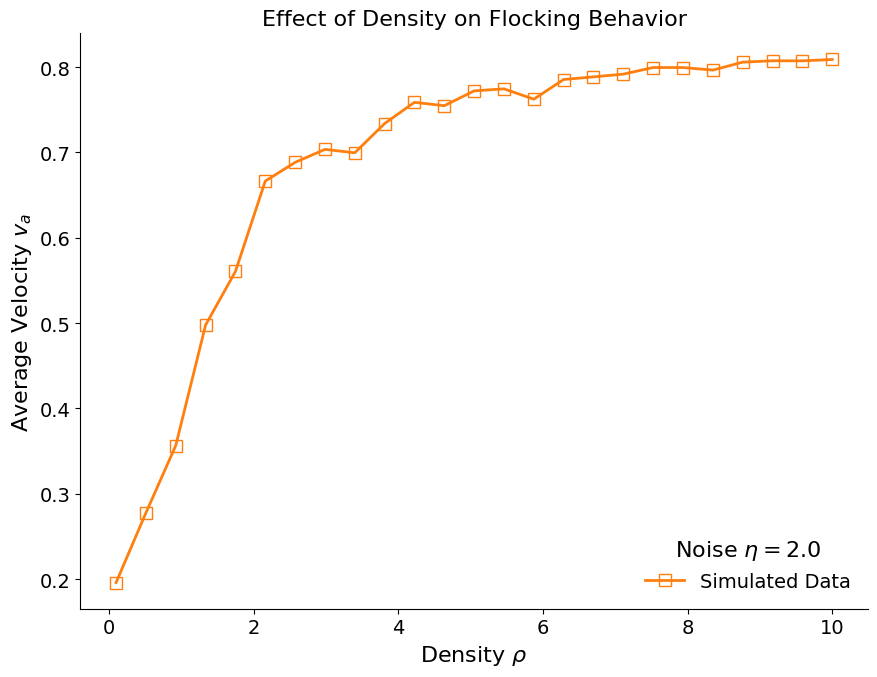

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# =============================================================================
# --- CORE SIMULATION ---
# =============================================================================

@njit
def vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y):
    """
    Advances the Vicsek model simulation by one time step using a Linked-Cell List.
    
    The Linked-Cell algorithm divides the simulation space into a grid. Instead of 
    checking every particle against every other particle [O(N^2) complexity], particles 
    only check for neighbors within their own cell and the 8 adjacent cells [O(N) complexity].
    This optimization is crucial for running large systems efficiently.
    """
    new_theta = np.zeros(N)
    r_sq = r_c**2

    total_cells = num_cells_x * num_cells_y
    # 'head' stores the index of the first particle located in each grid cell
    head = np.full(total_cells, -1, dtype=np.int32)
    # 'lscl' is the linked list itself, pointing from one particle to the next in the same cell
    lscl = np.full(N, -1, dtype=np.int32)

    # Step 1: Map particles to their respective spatial cells
    for i in range(N):
        cx = int(pos[i, 0] / cell_size_x) % num_cells_x
        cy = int(pos[i, 1] / cell_size_y) % num_cells_y
        c = cx + cy * num_cells_x
        
        # Link current particle to the previous head of the cell, then update the head
        lscl[i] = head[c]
        head[c] = i

    # Step 2: Compute local interactions for each cell
    for cx in range(num_cells_x):
        for cy in range(num_cells_y):
            c = cx + cy * num_cells_x
            i = head[c]

            # Iterate through all particles 'i' in the current cell
            while i != -1:
                sin_sum, cos_sum = 0.0, 0.0

                # Check the current cell and all 8 surrounding neighbors
                for dx_cell in (-1, 0, 1):
                    for dy_cell in (-1, 0, 1):
                        # Modulo operator handles the wrap-around for boundary cells
                        nx = (cx + dx_cell) % num_cells_x
                        ny = (cy + dy_cell) % num_cells_y
                        nc = nx + ny * num_cells_x

                        j = head[nc]
                        # Iterate through all particles 'j' in the neighboring cell
                        while j != -1:
                            dx = pos[j, 0] - pos[i, 0]
                            dy = pos[j, 1] - pos[i, 1]

                            # Apply Minimum Image Convention (Periodic Boundary Conditions)
                            # This ensures the shortest distance is calculated even if particles 
                            # are on opposite edges of the wrapped simulation box.
                            dx -= Lx * np.round(dx / Lx)
                            dy -= Ly * np.round(dy / Ly)

                            # If particle 'j' is within the interaction radius, sum its direction vector
                            if dx**2 + dy**2 <= r_sq:
                                sin_sum += np.sin(theta[j])
                                cos_sum += np.cos(theta[j])
                                
                            j = lscl[j]

                # Step 3: Compute the new heading
                # Average the local neighborhood directions and add uniform angular noise
                avg_theta = np.arctan2(sin_sum, cos_sum)
                noise = (np.random.rand() - 0.5) * eta
                new_theta[i] = avg_theta + noise
                
                i = lscl[i]

    # Step 4: Update particle positions based on their new headings
    for i in range(N):
        theta[i] = new_theta[i]
        # Move forward by velocity 'v', wrapping around the box boundaries
        pos[i, 0] = (pos[i, 0] + v * np.cos(theta[i])) % Lx
        pos[i, 1] = (pos[i, 1] + v * np.sin(theta[i])) % Ly

    return pos, theta

@njit
def run_rect_simulation(pos, theta, N, Lx, Ly, v, eta, steps, eq_steps):
    """
    Executes a full simulation run for a specific set of parameters.
    Separates the simulation into an 'equilibration' phase (to reach steady state) 
    and a 'measurement' phase (to calculate physical observables).
    """
    r_c = 1.0
    # Determine the number of grid cells. Cells must be at least as wide as the 
    # interaction radius (r_c) to guarantee all valid neighbors are checked.
    num_cells_x = max(1, int(Lx / r_c))
    num_cells_y = max(1, int(Ly / r_c))
    cell_size_x = Lx / num_cells_x
    cell_size_y = Ly / num_cells_y

    # Phase 1: Equilibration
    # Let the system evolve so initial random transients die out
    for _ in range(eq_steps):
        pos, theta = vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y)

    va_accum = 0.0
    measure_steps = steps - eq_steps
    
    # Phase 2: Measurement
    # Measure the global order parameter (v_a) at each step to find the time-average
    for _ in range(measure_steps):
        pos, theta = vicsek_step_rect_cell_list(pos, theta, N, Lx, Ly, v, r_c, eta, num_cells_x, num_cells_y, cell_size_x, cell_size_y)
        
        # Calculate the normalized average velocity vector. 
        # v_a ~ 1 means perfect alignment (flocking); v_a ~ 0 means complete disorder.
        vx, vy = np.sum(np.cos(theta)), np.sum(np.sin(theta))
        va_accum += np.sqrt(vx**2 + vy**2) / N

    return va_accum / measure_steps, pos, theta

# =============================================================================
# --- MAIN EXECUTION: DENSITY EXPERIMENT ---
# =============================================================================

def configure_matplotlib():
    """Sets consistent, publication-ready font sizes and line weights for plots."""
    plt.rcParams.update({
        'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 16,
        'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14,
        'lines.linewidth': 2, 'lines.markersize': 8
    })

def main():
    """
    Main execution block: The Density Phase Transition.
    Unlike the previous experiment which varied noise, this experiment keeps noise 
    constant and varies the particle density. 
    
    Physical concept: Higher density means particles interact more frequently, 
    allowing ordered flocking behavior to emerge even in the presence of noise.
    """
    v = 0.03
    num_trials = 5  # Using 5 trials to smooth out statistical fluctuations
    configure_matplotlib()

    print("--- Running Experiment 2: Effect of Density on Flocking ---")

    # FIXED GEOMETRY
    # We lock the box size. Area = 400 matches standard literature dimensions.
    Lx_fixed = 25.0
    Ly_fixed = 16.0
    Area = Lx_fixed * Ly_fixed

    # FIXED NOISE
    # A moderate noise level that permits both order and disorder depending on density
    eta_fixed = 2.0

    # Independent Variable: Density (rho = N / Area)
    rho_values = np.linspace(0.1, 10.0, 25)
    va_rho_results = []

    start_time_total = time.time()

    # Sweep through the different densities from sparse to crowded
    for rho in rho_values:
        # Calculate the required number of particles (N) to achieve the target density
        N_current = max(1, int(rho * Area))

        va_trial_sum = 0.0
        print(f"Simulating rho={rho:.2f} (N={N_current}) over {num_trials} trials... ", end="", flush=True)

        # Run an ensemble of trials for the current density
        for trial in range(num_trials):
            # Random uniform distribution of initial positions and headings
            pos = np.zeros((N_current, 2))
            pos[:, 0] = np.random.rand(N_current) * Lx_fixed
            pos[:, 1] = np.random.rand(N_current) * Ly_fixed
            theta = np.random.rand(N_current) * 2 * np.pi - np.pi

            va, _, _ = run_rect_simulation(pos, theta, N_current, Lx_fixed, Ly_fixed, v, eta_fixed, steps=2500, eq_steps=1000)
            va_trial_sum += va

        # Record the ensemble average of the order parameter
        va_averaged = va_trial_sum / num_trials
        va_rho_results.append(va_averaged)
        print(f"v_a = {va_averaged:.3f}")

    print(f"\nExperiment completed in {(time.time() - start_time_total)/60:.2f} minutes.")

    # --- Plotting the Results ---
    plt.figure(figsize=(9, 7))
    
    # Plotting v_a vs rho. We expect an upward curve, indicating that high density 
    # overcomes noise to produce macroscopic alignment.
    plt.plot(rho_values, va_rho_results, 's-', color='tab:orange', mfc='none', label='Simulated Data')

    plt.xlabel(r'Density $\rho$')
    plt.ylabel(r'Average Velocity $v_a$')
    plt.title('Effect of Density on Flocking Behavior')

    plt.legend(title=r'Noise $\eta=2.0$', title_fontsize=16, frameon=False, loc='lower right')

    # Aesthetic cleanup: remove top and right frame borders
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()